In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import svm
#from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_validate, GridSearchCV, KFold, cross_val_score
#from sklearn.metrics import recall_score

#from sklearn import preprocessing
from sklearn.preprocessing import RobustScaler, StandardScaler



In [ ]:
INPUT_DIR        = "data/input"
MODEL_INPUT_DIR  = f"{INPUT_DIR}/formatted-input"
#MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/model_input_traintest_cleavedSelf9k_hex_noID.csv"#model_input_traintest_randselfpeps_commonAlleles_nomhcnuggs_newPath.csv"#model_input_traintest_randselfpeps_new_pathogenicity.csv"#" #"model_input_imm_and_mhc-nb_m1_t7.csv"#"#"model_input_all_traintest.csv"
#MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/model_input_traintest_cleavedself9k_di_selfNoID.csv"
# MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/testMTEC_raw_featureTable_traintest_9kcleavedself.csv"
#MODEL_INPUT_FILE = f"data/selfsimilarity/selfsim_noID_combined.csv"
#FEATURE_TABLE    = f"{MODEL_INPUT_DIR}/featureTable1.csv"
MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/traintest_9kcleavedself_featureTable.csv"

#ALL_PEPS_FILE    = f"{INPUT_DIR}/cedar_randself_mhc-nbs.txt"

IMM_PEP_FILE     = f"{INPUT_DIR}/cedar_imm_peps_traintest.txt"#cedar_imm_9mers.txt"  #cedar_Immunogenic_self_df.txt"        #cedar_imm_peps_traintest.txt"
NON_IMM_PEP_FILE = f"{INPUT_DIR}/9kcleavedrandselfpeps.txt"#cedar_non-imm_9mers.txt"##randselfpeps~10k.txt"#cedar_non-imm_and_self_55.txt"#" #" #cedar_non_imm_peps_traintest.txt" #" #" randselfpeps~10k.txt cedar_non-imm_and_self_10    #"#randselfpeps~10k.txt"#random_in_silico_peptides.txt"#non_mhc_binding_peptides.txt"#"
#NON_IMM_PEP_FILE = f"{INPUT_DIR}/cedar_non_imm_peps_traintest.txt"
#NON_IMM_PEP_FILE = f"{INPUT_DIR}/9kcleavedselfpeps_nonBinders.txt"
NON_IMM_LABEL = "Non Imm"

# VALIDATION_MODEL_INPUT_FILE =  f"{MODEL_INPUT_DIR}/model_input_hormad1-magea4.csv"
# VALIDATION_PEPTIDES_FILE = f"{INPUT_DIR}/hormad1-magea4_cleavedPeps.txt"

## Load the Data

In [43]:
X_df = pd.read_csv(MODEL_INPUT_FILE)
#X_df = pd.read_csv(FEATURE_TABLE)
display(X_df[X_df['peptide'].str.contains('pep')])

# X_validation_df = pd.read_csv(VALIDATION_MODEL_INPUT_FILE)

,peptide,best_rank,avg_rank,strong_binders_count,weak_binders_count,best_netmhc_r,netmhc_a,best_mixmhc_r,mixmhc_a,best_mhcflurry_r,...,di_avg_score,di_best_a_score,di_avg_a_score,di_best_b_score,di_avg_b_score,di_best_c_score,di_avg_c_score,PRIME_%Rank_bestAllele,similarity_score,tap_score


In [44]:
X_df.drop_duplicates(subset=['peptide'], inplace=True)
X_df.sort_values(by='peptide', inplace=True)

display(X_df)
display(X_df.shape)

,peptide,best_rank,avg_rank,strong_binders_count,weak_binders_count,best_netmhc_r,netmhc_a,best_mixmhc_r,mixmhc_a,best_mhcflurry_r,...,di_avg_score,di_best_a_score,di_avg_a_score,di_best_b_score,di_avg_b_score,di_best_c_score,di_avg_c_score,PRIME_%Rank_bestAllele,similarity_score,tap_score
0,AAAAAAGVL,0.018,0.118000,13,25,0.255,HLA-C03:03,0.018,HLA-C03:03,0.081,...,0.825294,0.828742,0.654142,0.971572,0.865091,0.981934,0.908443,0.065,0.929204,0.5886
1,AAAAAAQQIQV,0.279,2.195000,1,2,5.282,HLA-A68:02,0.279,HLA-B51:08,1.024,...,0.782432,0.896026,0.623338,0.949169,0.805331,0.978184,0.870685,2.832,0.910891,0.4028
2,AAAAAAVAA,0.043,0.304667,6,12,0.690,HLA-B55:01,0.043,HLA-B45:01,0.181,...,0.837527,0.903314,0.692634,0.974613,0.863879,0.988599,0.913626,0.225,0.945455,0.3309
3,AAAAAGVSFTK,0.015,0.116333,6,15,0.272,HLA-A11:02,0.062,HLA-A03:02,0.015,...,0.796717,0.768044,0.669235,0.926138,0.831741,0.965046,0.854463,0.510,0.841608,0.7572
4,AAAAAPTTT,0.121,1.335333,2,10,3.244,HLA-B55:01,0.121,HLA-C12:04,0.641,...,0.807937,0.819793,0.638820,0.957885,0.837552,0.990274,0.897649,0.280,0.890566,0.7740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29293,YYVFHMPRCL,0.104,0.384667,0,9,0.635,HLA-C14:02,0.104,HLA-C14:03,0.415,...,0.650844,0.613803,0.357014,0.912071,0.723215,0.935935,0.790444,0.922,0.680435,0.7886
29294,YYVGYLQPRTF,0.014,0.047000,7,10,0.046,HLA-A24:03,0.014,HLA-C14:03,0.081,...,0.727760,0.782766,0.433589,0.964172,0.815213,0.974230,0.855855,0.758,0.890595,0.9316
29295,YYVHEGIRTY,0.005,0.015000,15,28,0.033,HLA-A26:01,0.005,HLA-C07:02,0.007,...,0.813675,0.934456,0.657942,0.972838,0.866823,0.988775,0.876161,0.566,0.813725,0.9371
29296,YYYAGSSRL,0.003,0.011000,14,30,0.003,HLA-C14:02,0.019,HLA-C14:02,0.011,...,0.731406,0.714564,0.506022,0.895387,0.832721,0.966470,0.802863,0.358,0.861314,0.7838


(29298, 24)

In [ ]:
# validationPepSet = pd.read_csv(VALIDATION_PEPTIDES_FILE, header=None)
# display(validationPepSet.shape)

# display(X_validation_df.shape)
# X_validation_df.drop_duplicates(subset=['peptide'], inplace=True)
# X_validation_df.sort_values(by='peptide', inplace=True)
# X_validation_df = X_validation_df[X_validation_df['peptide'].isin(validationPepSet[0])]

# print("HORMAD1 and MAGEA4 validation peptides")
# display(X_validation_df)
# display(X_validation_df.shape)

In [22]:
immPeps, non_immPeps = set(), set()

def addPeps(fp: str, pepSet: set):
    with open(fp, 'r') as f:
        for line in f:
            if line:
                pepSet.add(line.strip())

addPeps(IMM_PEP_FILE, immPeps)
addPeps(NON_IMM_PEP_FILE, non_immPeps)

labels_df = pd.DataFrame([
    {'peptide': pep, 'immunogenic': 1} for pep in immPeps
] + [
    {'peptide': pep, 'immunogenic': 0} for pep in non_immPeps
])

labels_df.sort_values(by='peptide', inplace=True)
labels_df.drop_duplicates(subset=['peptide'], inplace=True)

labels_to_drop = set(labels_df['peptide']) - set(X_df['peptide'])
labels_df = labels_df[~labels_df['peptide'].isin(labels_to_drop)]

display(labels_df.head(3))
display(labels_df.tail(3))

# Ensure peptides in feature df match those in the label df
label_peps = immPeps.copy()
label_peps.update(non_immPeps)
X_df = X_df[X_df['peptide'].isin(label_peps)]

print(f"Immunogenic: {len(immPeps)}")
print(f"Non-Immunogenic set: {len(non_immPeps)}")

,peptide,immunogenic
43,AAAAAAGVL,1
2433,AAAAAAVAA,1
5622,AAAAAGVSFTK,1


,peptide,immunogenic
6420,YYVGYLQPRTF,1
2561,YYVHEGIRTY,1
5397,YYYAGSSRL,1


Immunogenic: 9663
Non-Immunogenic set: 9800


#### Adding peptide length as a feature

In [45]:
X_df['length'] = X_df['peptide'].str.len()

#### 8mer missingness

In [46]:
print(f"Num 8mers in set with NaN for deepimmuno: {X_df[X_df['di_avg_a_score'].isna()].shape[0]}")

Num 8mers in set with NaN for deepimmuno: 1146


Drop Any Unwanted features

In [47]:
X_df = X_df.drop(columns=['Num_Tools_0_01', 'Num_Tools_0_02',
       'Num_Tools_0_03', 'Num_Tools_0_04', 'Num_Tools_1', 'Num_Tools_2', 'Num_Tools_Super_Strong_Binder',
       'Num_Tools_Strong_Binder', 'Num_Tools_Weak_Binder',
       'Num_Tools_Super_Weak_Binder'], errors='ignore')

X_df = X_df.drop(columns=['best_allele', 'best_netmhc_r', 'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r', 
       'netmhc_a', 'mixmhc_a', 'mhcflurry_a', 'mhcnuggets_a'], errors='ignore')

display(X_df.shape)

(29298, 19)

#### Get numpy array

In [26]:
X = X_df.drop(columns='peptide').to_numpy()
display(X)

y = labels_df.drop(columns='peptide').to_numpy()
y=y.ravel()
display(y)

array([[1.80000000e-02, 1.18000000e-01, 1.30000000e+01, ...,
        9.29203510e-01, 5.88600000e-01, 9.00000000e+00],
       [4.30000000e-02, 3.04666667e-01, 6.00000000e+00, ...,
        9.45454538e-01, 3.30900000e-01, 9.00000000e+00],
       [1.50000000e-02, 1.16333333e-01, 6.00000000e+00, ...,
        8.41607571e-01, 7.57200000e-01, 1.10000000e+01],
       ...,
       [1.40000000e-02, 4.70000000e-02, 7.00000000e+00, ...,
        8.90595019e-01, 9.31600000e-01, 1.10000000e+01],
       [5.00000000e-03, 1.50000000e-02, 1.50000000e+01, ...,
        8.13725471e-01, 9.37100000e-01, 1.00000000e+01],
       [3.00000000e-03, 1.10000000e-02, 1.40000000e+01, ...,
        8.61313879e-01, 7.83800000e-01, 9.00000000e+00]],
      shape=(19463, 18))

array([1, 1, 1, ..., 1, 1, 1], shape=(19463,))

In [27]:
print(X.dtype)
#print(X_df_final.drop(columns='peptide').dtypes)

float64


In [28]:
feature_cols = X_df.drop(columns='peptide').columns
print(feature_cols)

Index(['best_rank', 'avg_rank', 'strong_binders_count', 'weak_binders_count',
       'mtec_expression_count', 'pathogenicity', 'di_best_score',
       'di_avg_score', 'di_best_a_score', 'di_avg_a_score', 'di_best_b_score',
       'di_avg_b_score', 'di_best_c_score', 'di_avg_c_score',
       'PRIME_%Rank_bestAllele', 'similarity_score', 'tap_score', 'length'],
      dtype='str')


## Visualize data

Violin Plots

In [48]:
CEDAR_IMM           = 'data/input/cedar_imm_peps_traintest.txt'
CEDAR_NON_IMM       = 'data/input/cedar_non_imm_peps_traintest.txt'
RAND_CLEAVED_SELF   = 'data/input/9kcleavedrandselfpeps.txt'

imm_peps        = pd.read_csv(CEDAR_IMM, header=None)[0].to_list()
non_imm_peps    = pd.read_csv(CEDAR_NON_IMM, header=None)[0].to_list()
self_peps       = pd.read_csv(RAND_CLEAVED_SELF, header=None)[0].to_list()

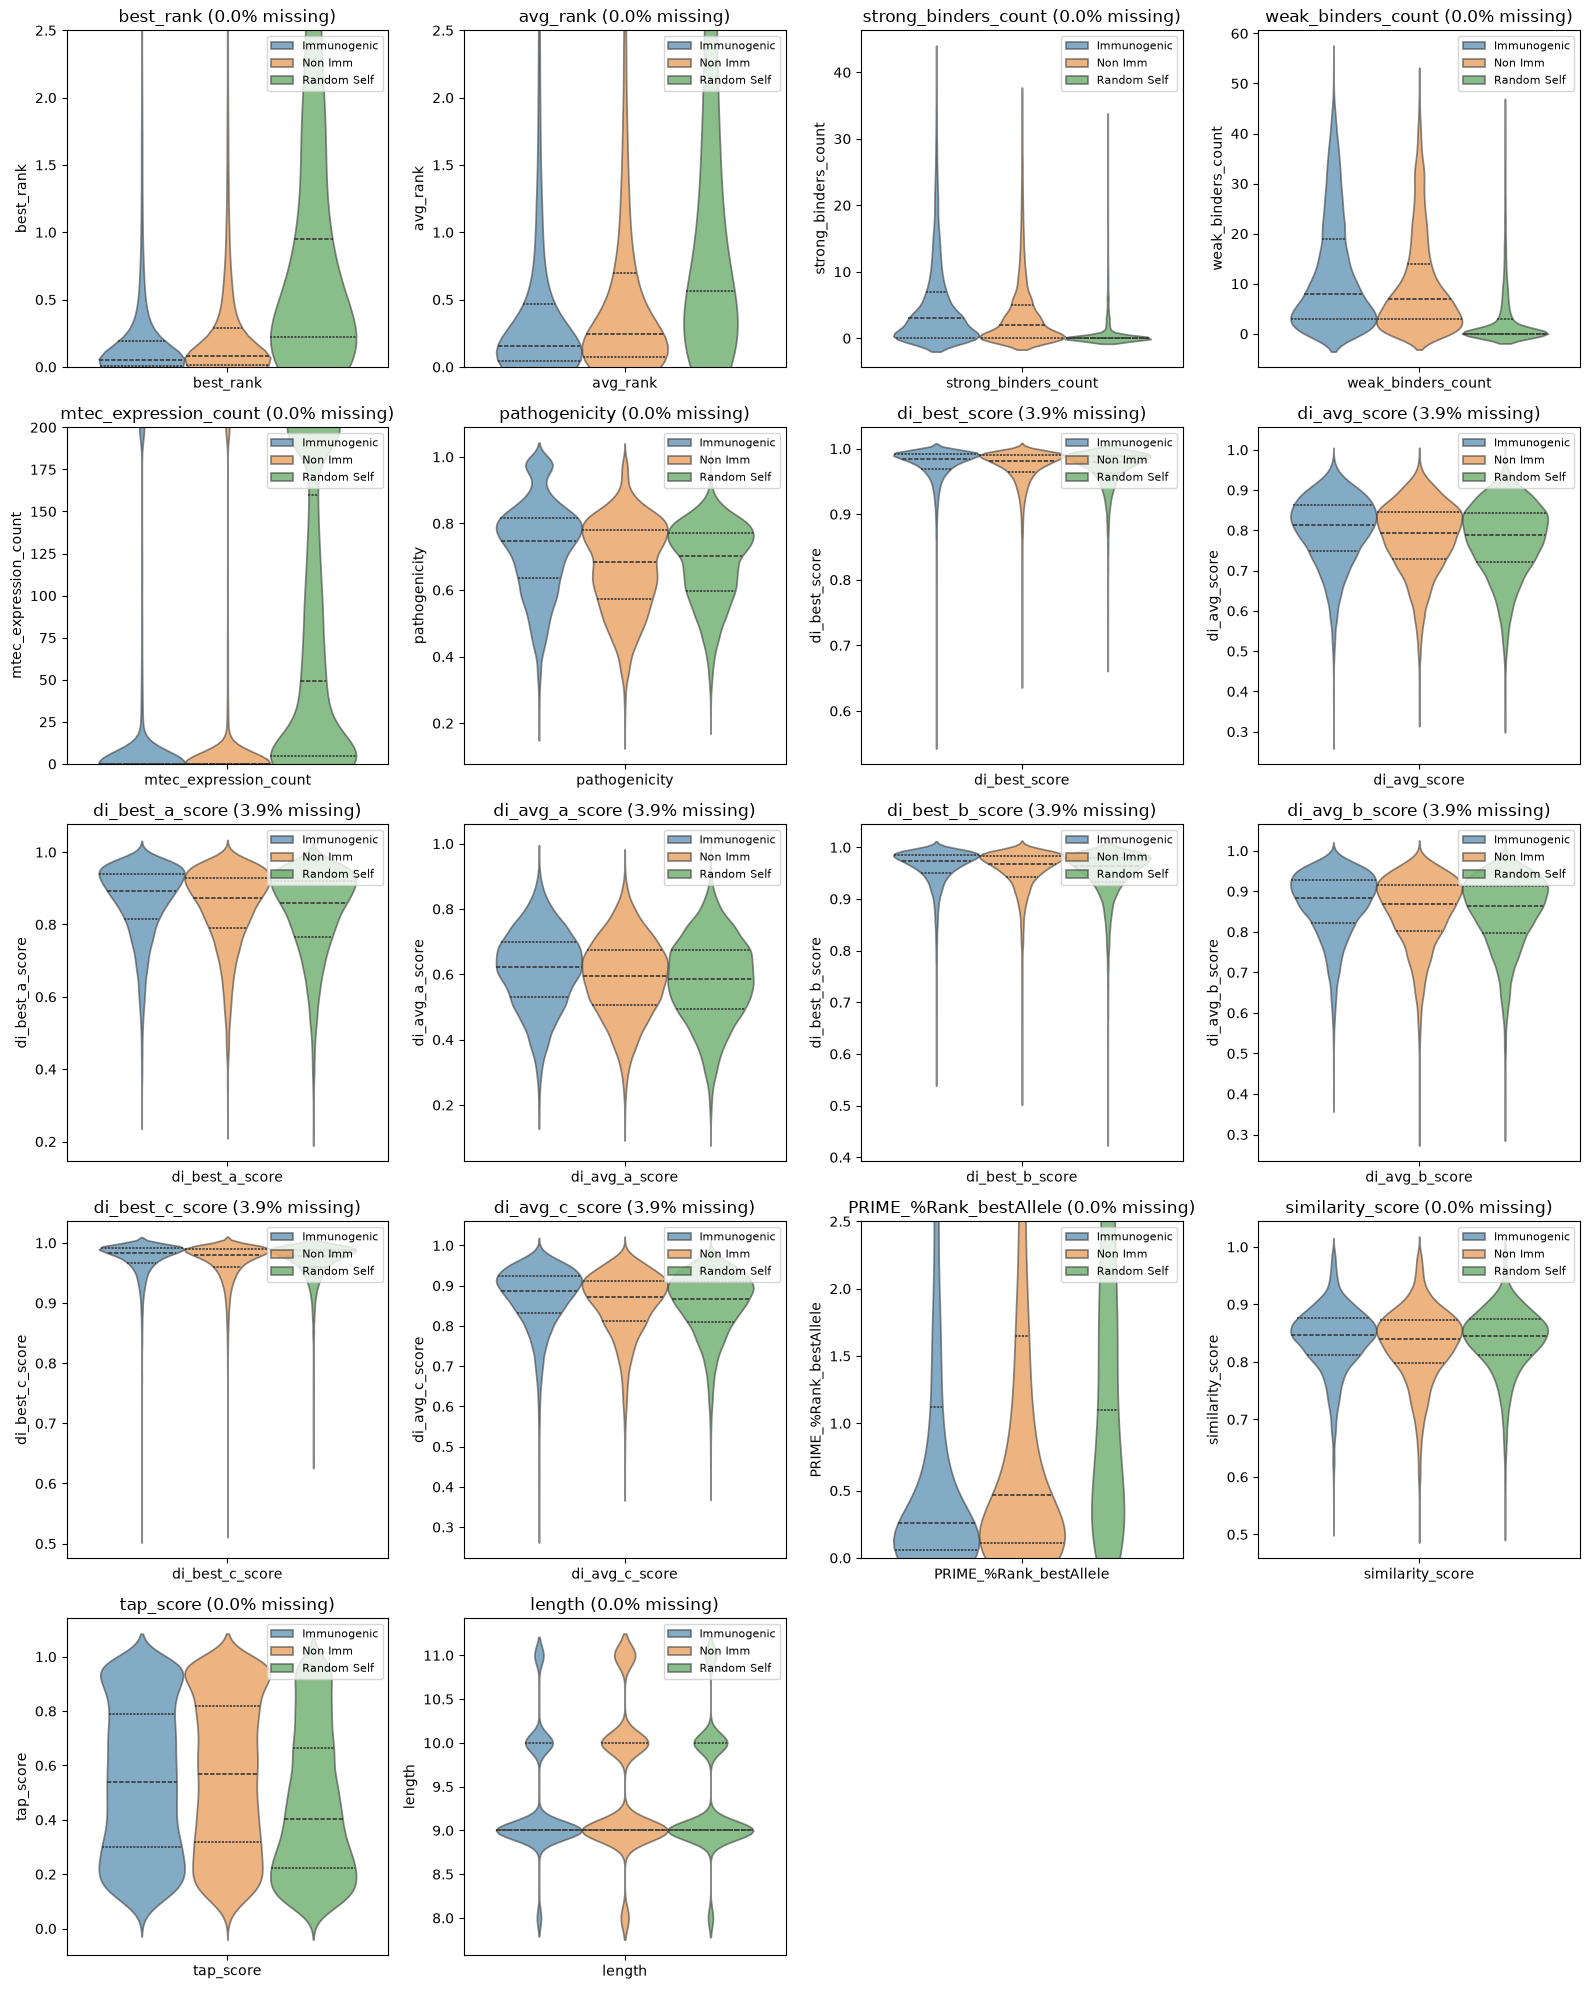

In [57]:

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plotViolinsSplit(X_df, feature_cols, groups):
    peptide_to_group = {}
    for group_name, peptides in groups.items():
        for pep in peptides:
            peptide_to_group[pep] = group_name

    df = X_df.copy()
    df['group'] = df['peptide'].map(peptide_to_group)
    df = df[df['group'].notna()]

    group_labels = list(groups.keys())
    can_split = len(group_labels) == 2

    fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
    axes = axes.flatten()

    for i, feature in enumerate(feature_cols):
        col = df[feature]
        n_missing = col.isna().sum()
        pct_missing = 100 * n_missing / len(col)

        restrict_range = ('_r' in feature) or ('PRIME' in feature)
        cap_mtec_expression = (feature == 'mtec_expression_count')

        vals = col.copy()
        if restrict_range:
            vals = vals.clip(0, 5)
        elif cap_mtec_expression:
            vals = vals.clip(0, 200)

        plot_df = pd.DataFrame({'value': vals, 'group': df['group'], 'x': feature})
        plot_df = plot_df.dropna(subset=['value'])

        sns.violinplot(
            data=plot_df, x='x', y='value', hue='group', split=can_split,
            ax=axes[i], hue_order=group_labels, inner='quartile', alpha=0.6,
            #cut=0
        )
        axes[i].set_title(f'{feature} ({pct_missing:.1f}% missing)')
        axes[i].set_xlabel('')
        axes[i].set_ylabel(feature)
        axes[i].legend(loc='upper right', fontsize=8)

        if restrict_range:
            axes[i].set_ylim(0, 2.5)
        elif cap_mtec_expression:
            axes[i].set_ylim(0, 200)


    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    #plt.tight_layout(pad=2.5, w_pad=2.0, h_pad=3.0)
    plt.show()

plotViolinsSplit(X_df, feature_cols, {'Immunogenic': imm_peps, 'Non Imm': non_imm_peps, 'Random Self': self_peps})

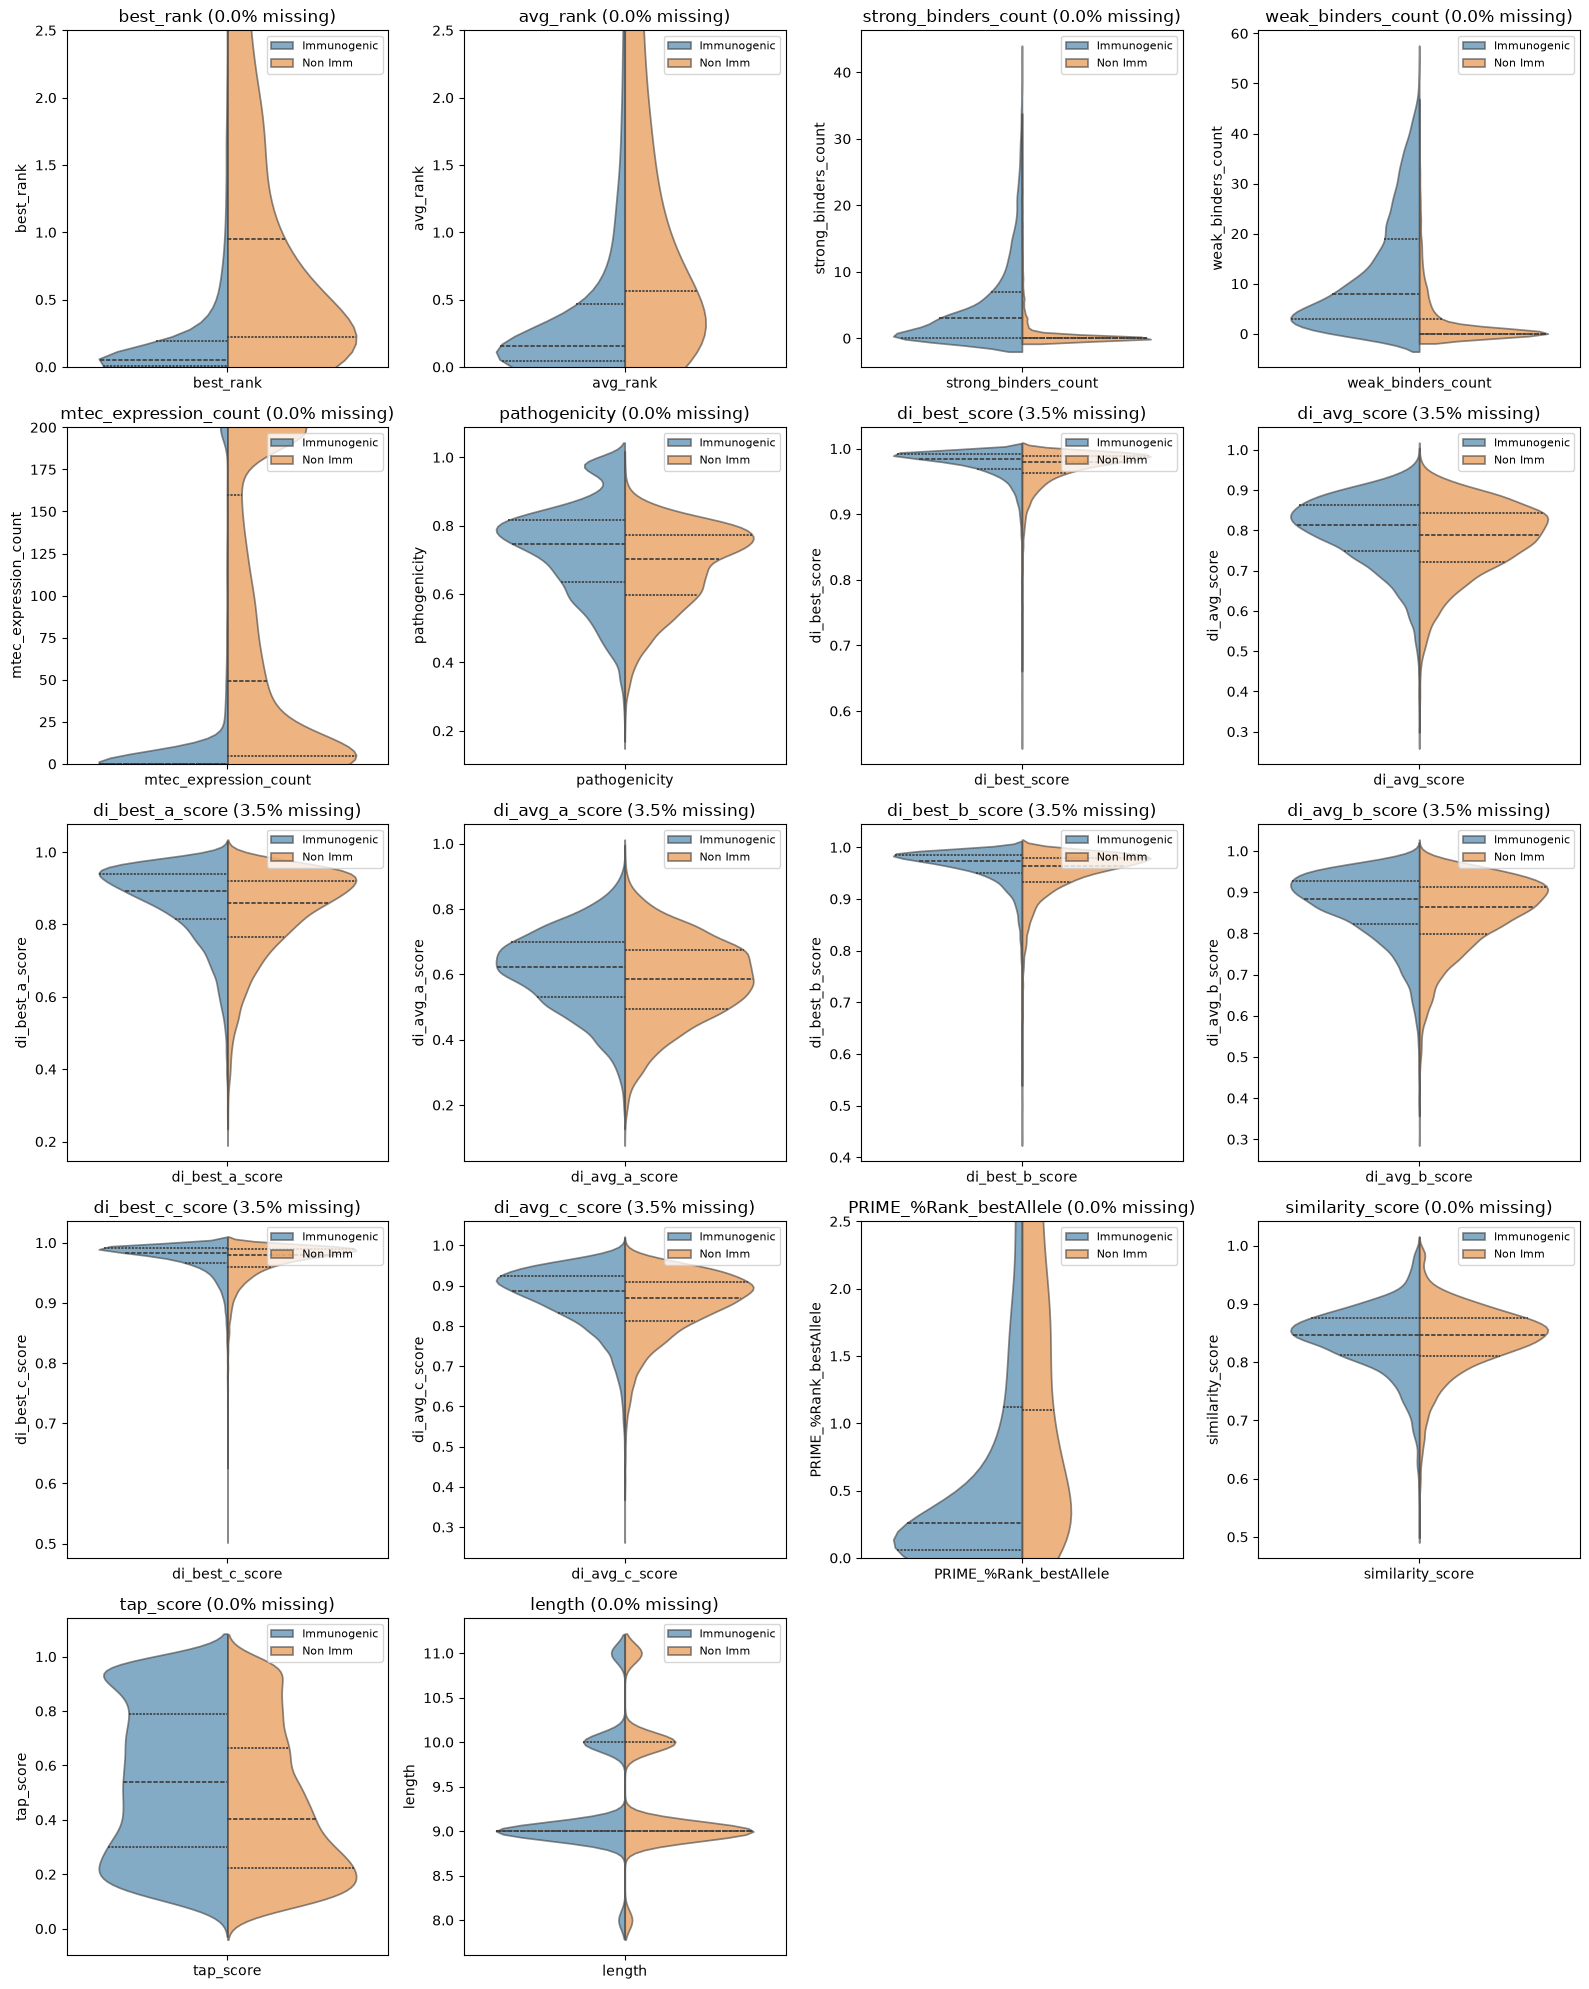

In [ ]:
# import seaborn as sns
# import pandas as pd

# def plotViolinsSplit(X, feature_cols, labels):
#     fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
#     axes = axes.flatten()

#     for i, feature in enumerate(feature_cols):
#         col = X[:, i]
#         not_nan = ~np.isnan(col)
#         mask = not_nan & np.isin(y, [0, 1])

#         vals = col[mask]
#         groups = np.where(y[mask] == 1, labels[0], labels[1])

#         n_missing = np.isnan(col).sum()
#         pct_missing = 100 * n_missing / len(col)

#         restrict_range = ('_r' in feature) or ('PRIME' in feature)
#         cap_mtec_expression = (feature == 'mtec_expression_count')

#         if restrict_range:
#             vals = np.clip(vals, 0, 5)
#         elif cap_mtec_expression:
#             vals = np.clip(vals, 0, 200)

#         df = pd.DataFrame({'value': vals, 'group': groups, 'x': feature})

#         sns.violinplot(
#             data=df, x='x', y='value', hue='group', split=True,
#             ax=axes[i], hue_order=labels, inner='quartile', alpha=0.6
#         )
#         axes[i].set_title(f'{feature} ({pct_missing:.1f}% missing)')
#         axes[i].set_xlabel('')
#         axes[i].set_ylabel(feature)
#         axes[i].legend(loc='upper right', fontsize=8)

#         if restrict_range:
#             axes[i].set_ylim(0, 2.5)
#         elif cap_mtec_expression:
#             axes[i].set_ylim(0, 200)

#     for j in range(i + 1, len(axes)):
#         axes[j].set_visible(False)

#     plt.tight_layout()
#     plt.show()

# #plotViolinsSplit(X, feature_cols, ['Immunogenic', NON_IMM_LABEL])
# plotViolinsSplit(X, feature_cols, ['Immunogenic', NON_IMM_LABEL])